# Lab 065 · Extract query representations without their own labels

[Lesson](../lessons/0065-tabpfn-query-embeddings.html) · [Reference](../reference/0065-tabpfn-query-embeddings.html) · [Author measurements](_verify_l065_v2_results.json) · [Reproduction](l065-reproduction.md)

**Skill:** extract role-correct pretrained representations, preserve row identity and freeze a validation-selected head. **Four TODOs** drive the actual full 12-layer v2 checkpoint, with PROVIDED model code visible below. **CHECK** diagnoses errors; **EXIT** saves a measured artifact and interpretation. Built with TabPFN · [Prior Labs License](sources/foundation/v2-LICENSE). CPU supported; checkpoint download and 894 head candidates make this a substantial lab. Default run: all 768 diabetes rows, seed 7, ten folds; the author uses three full datasets and three seeds. No encoder training occurs. Full 29-dataset paper benchmark: NOT_RUN.

### Running on Google Colab?

Colab opens only this single file, so the course package (`relkit`) and the lab
dependencies (xgboost, lightgbm, catboost, …) are **not** present by default. The cell
below fixes that: on Colab it shallow-clones the course repo, installs
`requirements-labs.txt`, and switches into `labs/` so `relkit` imports and the data cache
resolve. **On a local venv or your own Jupyter it does nothing — just run it and continue.**

In [ ]:
# @colab-bootstrap — PROVIDED. Makes the lab self-sufficient on Google Colab; a no-op elsewhere.
import os, sys

if "google.colab" in sys.modules:
    if not os.path.isdir("/content/relational"):
        !git clone --depth 1 https://github.com/Avistian/relational.git /content/relational
    %pip install -q -r /content/relational/requirements-labs.txt
    os.chdir("/content/relational/labs")
    print("Colab ready — working dir:", os.getcwd())
else:
    print("Not on Colab — using the local environment as-is.")

## A representation inherits the information used to produce it

<a href="../lessons/0064-tabpfn-v2.html">The v2 forward pass</a> ends in a query target state before the class decoder. That state can be reused as a feature vector, but its meaning depends on context and role. This lesson connects hidden-state extraction to out-of-fold learning: a representation that already received its own label is not an honest input for evaluating a new probe.

**Connecting the ideas.** A frozen encoder is still a conditional function of its supplied data. Context states can contain their labels; query states are produced without that direct target input. Freezing weights therefore does not remove the need to audit extraction roles.

## A representation is a computation with an information boundary

Your skill in this lesson is to turn a frozen TabPFN v2 into a useful feature extractor **without giving a training row its own answer**. You will implement ten-fold extraction, restore row identities, concatenate selected layer states, and train a validation-selected linear head. The backbone is the full historical model from Lesson 064: 12 distinct layers, 192 hidden coordinates, six attention heads, and every released parameter loaded. The four new tasks run that real model on a complete dataset.

Start with retrieval. What is a query allowed to attend to in v2? What does “frozen” describe: weights, inputs, or both? Why can choosing a hyperparameter on test data invalidate a test score even if no gradient ever touches that data? Try answering before reading further.

A **representation**, or embedding, is a vector computed for a row. A **linear probe** trains a linear classifier on that vector to measure how accessible the target is to a simple decision rule. Neither the vector's dimensionality nor a clean scatter plot tells us whether it is legitimate input at deployment. We must know which features, labels, context rows, preprocessing statistics, and fitted parameters produced it.

This distinction matters to the relational mission. Suppose a customer representation aggregates related transactions. A transaction outcome that became known after the prediction time can enter a representation even if the final classifier uses a clean temporal split. TabPFN gives us a compact, runnable example of the same audit: label information can enter a forward pass through context, without fitting any weights on the evaluated row.

## Read the paper as a mechanism, then inspect the release

The primary reading is [Ye, Liu and Chao, *A Closer Look at TabPFN v2*, version 1, §6](https://arxiv.org/html/2502.17361v1#S6). Read all three subsections, Figure 5, Table 2 and Appendix C Table 10 together. The paper extracts held-out training folds as queries, uses ten folds for its visual experiment, compares layers 6, 9 and 12, and evaluates validation-selected concatenations of up to three of the 12 layers over 29 classification datasets. Its probe is logistic regression. The broader evaluation setup in §4.1 uses 64/16/20 train/validation/test partitions and 15 seeds. Our three-dataset, three-seed numeric experiment is a mechanism study, not that benchmark.

The paper's qualitative observation is that role-correct representations can make a simple head competitive with the native predictor. That is a statement about an extraction-and-evaluation procedure. It does not establish that every layer is linearly separable or that the coordinates have causal meaning. Figure 5's two-dimensional displays cannot substitute for the held-out linear-head measurements. Table 10 also includes cases where selecting a combination does not improve test accuracy. The [frozen paper-table audit](_paper_l065_v2_results.json) counts 16 combined wins, 4 ties and 9 losses against native v2. For pc3, combined accuracy is 88.82% versus native 89.46%, although layer 6 scores 90.10%; validation selection need not pick the test winner. Published Table 2 average ranks and ranks reconstructed from rounded Table 10 values are different summaries; the audit retains both without calling rounded-score differences a paper error.

The [historical 2.0.9 release](https://pypi.org/project/tabpfn/2.0.9/) makes an easily missed API detail concrete. `get_embeddings(X, data_source='train')` selects **context states**; `X` still supplies the query rows for that model call. Changing the string to `test` selects query states. It does not automatically cross-fit the training table. The release's `model/transformer.py` takes the final token on the group axis; `utils.py::_get_embeddings` chooses the context or query output. The lab compares its full layer stack and final extraction with that API on the same fixture.

## Why context and query states answer different questions

Let C be the number of labeled context rows, Q the number of query rows, G the number of two-feature groups, and D=192 the hidden width. After layer ℓ, the model state is H^(ℓ) with shape B×(C+Q)×(G+1)×D. B is the number of tables processed together; our experiment uses B=1. The last of the G+1 tokens is the target token. The desired query embedding is therefore:

`Z_query^(ℓ) = H^(ℓ)[:, C:, -1, :]`.

The two slices answer different questions. `C:` selects receiver rows whose targets were unavailable. `-1` selects the target token within each row. Taking the last **row** would return one query, not one representation per query. Averaging over feature groups would produce a different representation from the one inspected in the paper and release. Capturing the block output includes its final residual and normalization; capturing a sublayer's input is a different layer convention.

A context target token starts from an observed label. A query target token starts from the context-mean-imputed label, converted to a rank, together with the missingness flag −2. The dummy representation is not an all-zero vector. For binary context labels [0,0,1], the filled query value is 1/3. The historical rank encoder counts the distinct context labels below it, producing rank 1; the flag still distinguishes it from an observed class-1 target. These target inputs are linearly encoded before the attention stack.

Consider two identical feature rows assigned opposite labels. Their context target inputs differ immediately. A head may learn to read that difference after the transformer, even though a new query with identical features has no corresponding observed label channel. A perfect training plot can therefore be a symptom of information-role mismatch. Scaling or rotating those coordinates cannot restore an unavailable deployment input.

<div style="max-width:100%;overflow-x:auto" role="region" aria-label="Scrollable computational figure"><img alt="Left: synthetic target-encoder inputs with context labels [0,0,1]. Right: measured own-label flip on the fixed release-check fixture, with all identities and query batches held fixed." src="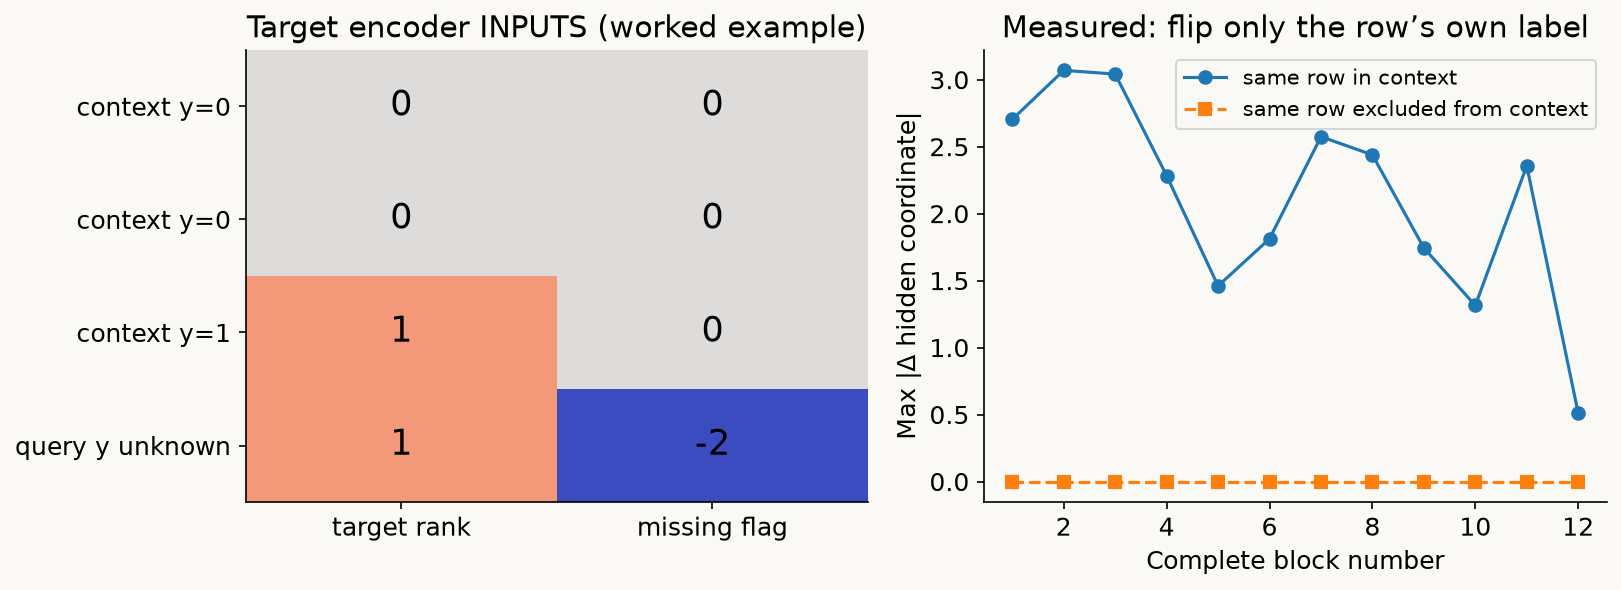" style="width:100%;min-width:900px;max-width:none;height:auto"></div>

Left: synthetic target-encoder inputs with context labels [0,0,1]. Right: measured own-label flip on the fixed release-check fixture, with all identities and query batches held fixed. [Full-size figure](figures/l065/roles-v2.png).

**Connecting the ideas.** To use query-role vectors for supervised training, each row must temporarily leave the labeled context. Fold extraction implements that requirement and scatters one vector back to each original row ID, connecting the encoder to the later probe dataset.

The counterfactual must hold the relevant operator fixed. In the lab we flip row 0's target while retaining the same features, row identities, fold assignment, context membership, group-identity seed, preprocessing recipe and query batch. When row 0 is excluded from context, its representation is exactly unchanged because the changed label never enters the model call. When it is a context row, its hidden state changes. Neither test recomputes stratified folds after changing the label; doing so would change context membership and answer another question.

Lesson 064 adds an important boundary: masked attention alone does not guarantee complete-wrapper query independence. The historical uncached encoder counts varying channels across all supplied rows. A changed query batch can alter that preprocessing quantity in certain partly missing constant-feature cases. We therefore keep the query batch fixed for label interventions and record batches in the experiment. Own-label exclusion and query-batch independence are separate properties.

## Ten folds, one vector per original row

Let T be the outer training row IDs. Partition them into K=10 folds F₀,…,F₉. For each k, context Sₖ=T∖Fₖ supplies features and known labels. Rows in Fₖ supply query features only. For row i in Fₖ we compute zᵢ^(ℓ)=gθ^(ℓ)(xᵢ; Sₖ). The semicolon emphasizes that labeled context is an input. Frozen θ does not remove that conditioning.

Each forward yields approximately one tenth of the training representations, at every layer. An empty allocation of shape |T|×12×192 receives those representations at the original training positions. This is a **scatter** operation: destinations are explicit indices. Merely concatenating fold outputs changes row order. For positions [0,1,2,3,4,5] with fold IDs [1,0,1,0,2,2], fold traversal returns positions [1,3], then [0,2], then [4,5]. Concatenation would attach the second row's vector to the first row's label. The shape would still look correct.

<div style="max-width:100%;overflow-x:auto" role="region" aria-label="Scrollable computational figure"><img alt="Synthetic identity trace. Concatenation has the correct length but the wrong row-label alignment; scatter restores original destinations." src="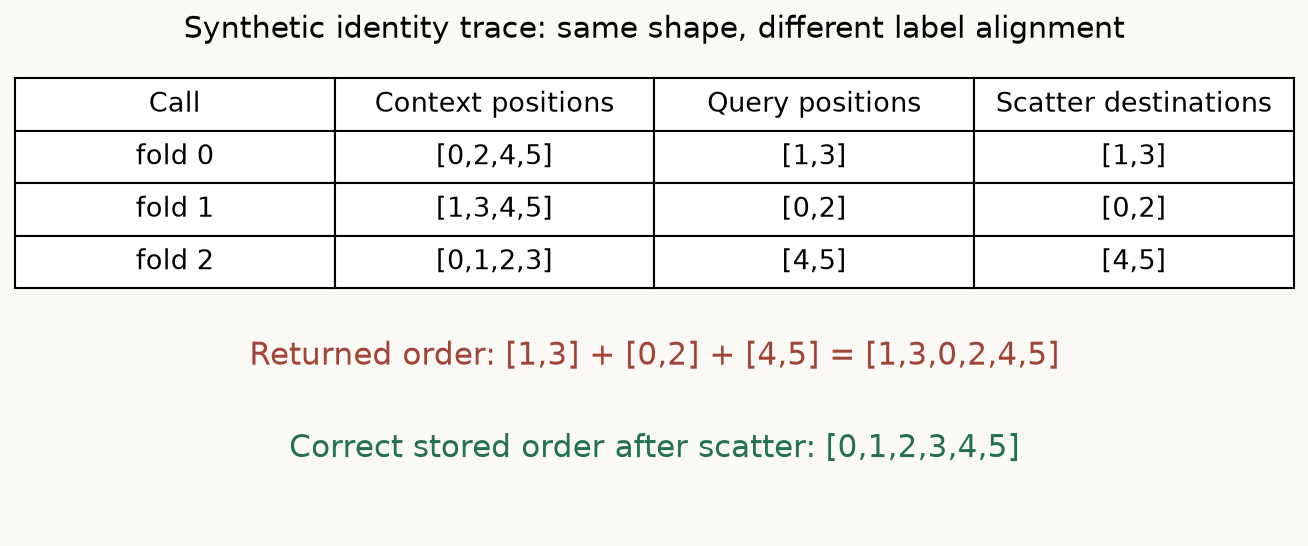" style="width:100%;min-width:720px;max-width:none;height:auto"></div>

Synthetic identity trace. Concatenation has the correct length but the wrong row-label alignment; scatter restores original destinations. [Full-size figure](figures/l065/scatter-v2.png).

### Query embeddings: freeze the encoder, learn a new readout

**Trace before reading:** Why must a training row be extracted as a query rather than as labeled context?

<div style="max-width:100%;overflow-x:auto">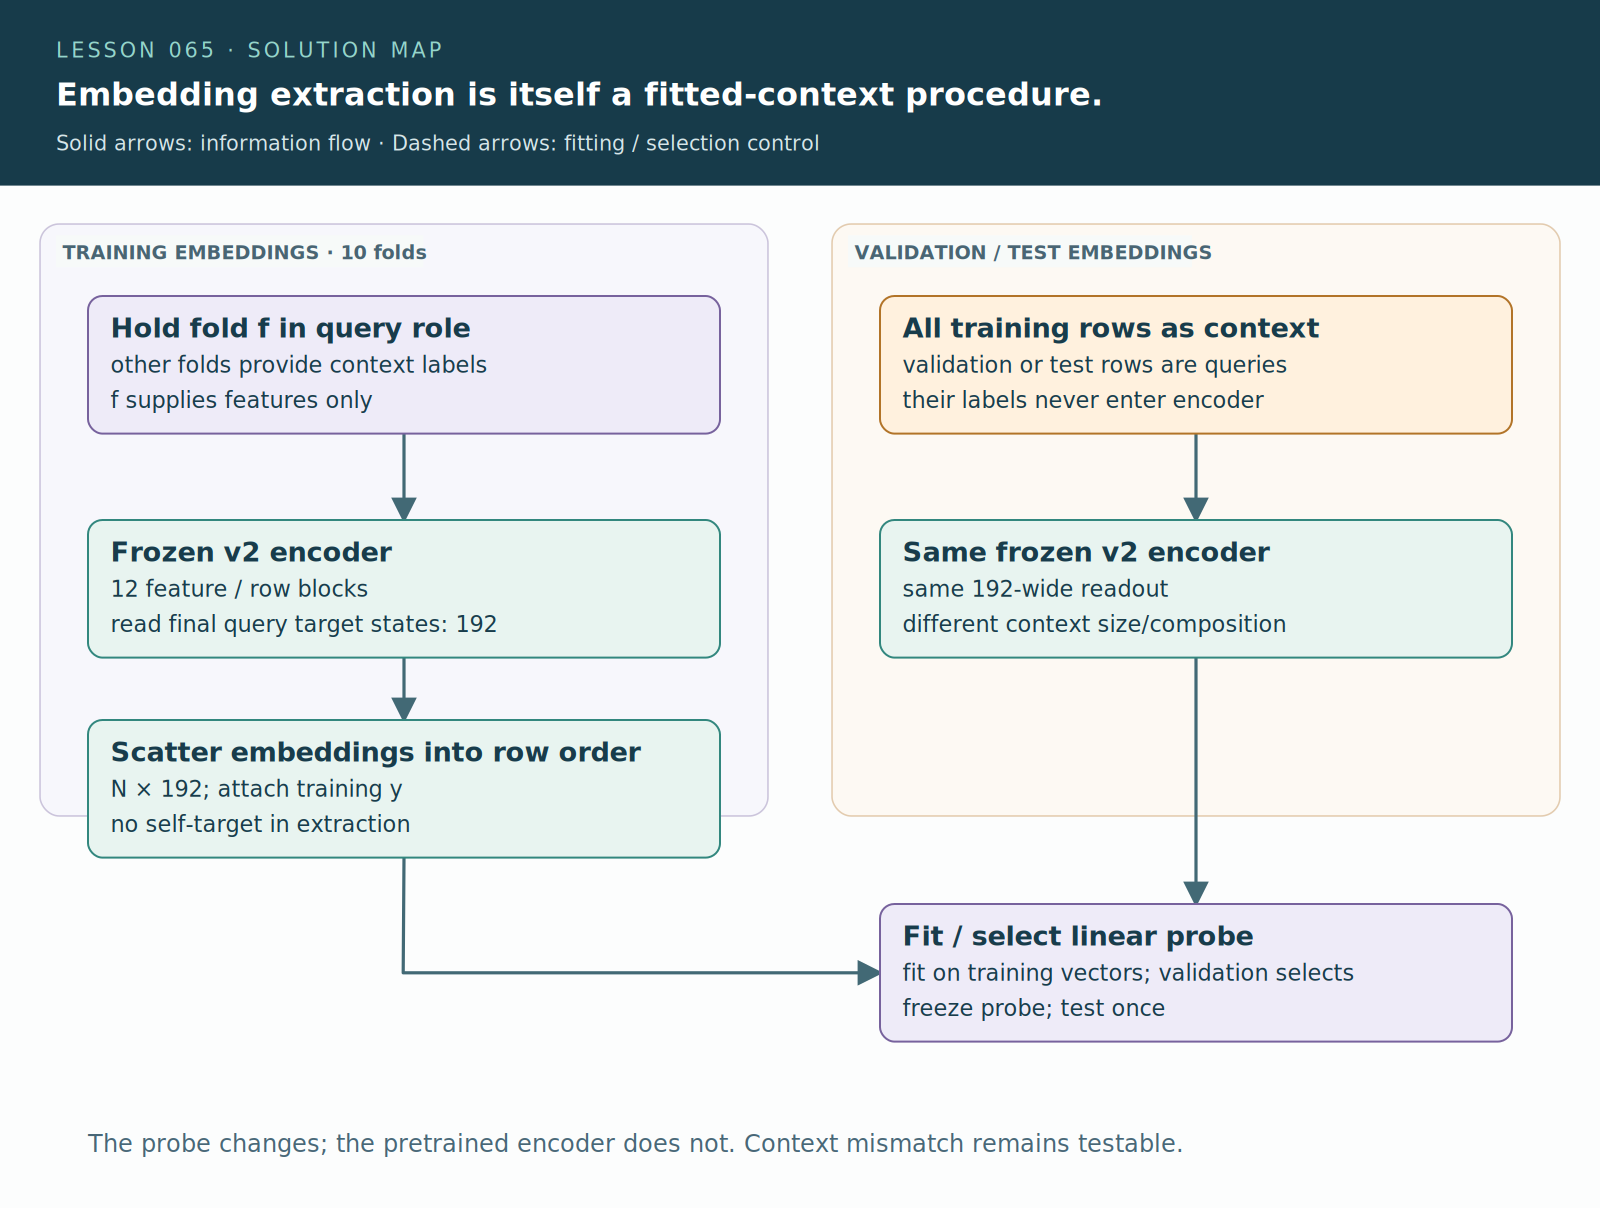</div>

**How the parts work together:** A labeled context state can already contain that row’s target. Query-role extraction removes this direct path: each training fold is embedded using only other-fold labels, then scattered to original row order before probe fitting.

**Pictured scope:** Lesson’s ten-fold query-role training extraction and full-training evaluation context. Frozen historical TabPFN v2; preprocessing/representation mismatch is measured, not assumed away.

[Full-size vector diagram](../assets/solution-maps/0065-embedding-probe.svg). Scroll on narrow screens to keep labels legible.

<details><summary>Text route: components and connections</summary><ol><li><strong>Hold fold f in query role</strong>: other folds provide context labels; f supplies features only. Connects to Frozen v2 encoder.</li><li><strong>All training rows as context</strong>: validation or test rows are queries; their labels never enter encoder. Connects to Same frozen v2 encoder.</li><li><strong>Frozen v2 encoder</strong>: 12 feature / row blocks; read final query target states: 192. Connects to Scatter embeddings into row order.</li><li><strong>Same frozen v2 encoder</strong>: same 192-wide readout; different context size/composition. Connects to Fit / select linear probe.</li><li><strong>Scatter embeddings into row order</strong>: N × 192; attach training y; no self-target in extraction. Connects to Fit / select linear probe.</li><li><strong>Fit / select linear probe</strong>: fit on training vectors; validation selects; freeze probe; test once.</li></ol></details>

The CHECK uses identity-coded vectors rather than only shape assertions. Each vector carries its query position, so the restored first coordinate must read [0,1,2,3,4,5]. It also checks that no query ID occurs in its own context, each row is written once, and layer/width dimensions agree across folds. These are independent obligations: preserving shape does not imply preserving identity, and preserving identity does not imply excluding the label.

Ten folds trade computation for context coverage. Each training representation sees roughly 90% of T as support, and the backbone runs ten times. Leave-one-out would retain |T|−1 context rows but require |T| forwards. This lab captures all 12 layer states during each forward with hooks; evaluating another layer does not require another transformer pass. Keeping all states uses memory proportional to rows×12×192, while computing them still incurs the full attention cost.

## Model architecture: frozen encoder, fitted probe, explicit evaluation context

The diagram follows the actual runnable path. Numeric inputs first lose columns constant within the particular context. The model pairs remaining features, computes context-based replacement and sample normalization, adds group identities, appends the target token, and runs all 12 pretrained blocks. Within each block, feature attention mixes tokens inside a row; row attention receives only labeled context senders; the feed-forward map acts on each token. Context receivers use all six key/value heads. Query receivers share the first context key/value head across six separate query heads. The model is unchanged from Lesson 064.

The released group identity is added after the value encoder; the schematic multiplication in Ye §5 Eq. 2 is not its exact grouped-feature forward. A [zero-normalized-value source fixture](_token_identity_l065_results.json) makes the difference observable before the first block. This lesson uses the checked release operation.

The extraction branch takes the target state after each complete block, before the native prediction head. The native branch takes the final query target state through the released 192→768→10 head, keeps the two active classes, divides logits by temperature 0.9, and applies softmax. These branches share the checkpoint and outer rows; the extracted-feature branch additionally learns a head from the outer training data.

<div style="max-width:100%;overflow-x:auto" role="region" aria-label="Scrollable computational figure"></div>

Actual experiment: ten query-role training folds; full-training evaluation context; all 12 target states; validation-only layer/C selection; untouched test comparison. The frozen network is complete historical v2. [Full-size figure](figures/l065/architecture-v2.png).

**Connecting the ideas.** With valid vectors in hand, the new head becomes an ordinary supervised learner. Its fitted coefficients can improve the readout without changing the pretrained representation. Keep the encoder context policy separate from the head’s optimization.

**Connecting the ideas.** Choosing a probe or regularization strength adapts to validation. That familiar selection boundary applies even though the encoder is frozen. Evaluate the chosen head once, then diagnose whether extraction-context mismatch contributed to its result.

At validation and test, this local protocol uses **all outer training rows as labeled context**, with separate fixed validation and test query batches. The paper's §6 does not fully specify that policy or an evaluation-context averaging rule. Full training context is an explicit local choice. It preserves query role, but support coverage changes from about 90% for head-training vectors to 100% for evaluation vectors. Query-role alignment does not guarantee identical representation distributions.

Our historical experiment remains in `_verify_l065_results.json`: it used three folds, only final-layer states, and averaged evaluation embeddings over fold contexts. Those numbers belong to that older operator. The new run has ten folds, all-layer extraction, and the declared full-context evaluation policy. Averaging embeddings would also differ from averaging head probabilities: a linear logit commutes with averaging, but a sigmoid or softmax does not.

## Derive what the linear head learns

For selected one-based layers A=(a₁,…,aᵣ), with 1≤r≤3, concatenate their vectors in that order: zᵢ=[zᵢ^(a₁);…;zᵢ^(aᵣ)]. Its width is 192r. Concatenation retains separate coordinates; averaging would compress them into 192 coordinates and prevent the head from independently weighting layer-specific signals. The TODO validates distinct available layers and preserves the requested order.

Fit a separate mean μⱼ and scale sⱼ for each coordinate **on head-training representations only**. Standardization gives uᵢⱼ=(zᵢⱼ−μⱼ)/sⱼ. The same μ and s transform validation and test vectors. Without this boundary, evaluation rows would participate in a fitted transformation. Without scaling, the L2 penalty could treat a large-unit coordinate differently from an equivalent rescaled one.

For our binary datasets, the head computes aᵢ=wᵀuᵢ+b and pᵢ=1/(1+exp(−aᵢ)). Negative log likelihood is −yᵢ log pᵢ−(1−yᵢ)log(1−pᵢ). The solver balances summed training loss against an L2 coefficient penalty; larger C weakens regularization. The provided `fit_head` visibly fits the scaler and sklearn's `liblinear` logistic solver. This is a permitted peripheral optimizer, not a hidden replacement for extraction or the model. Liblinear's synthetic intercept is also regularized with its default intercept scaling. The training routine checks that the iteration limit was not reached.

The head's fitted training accuracy is not an unbiased estimate of its future accuracy. Its targets have now been used to optimize w and b, even though they were excluded from their own representation construction. Cross-fitting repairs one information route; it does not turn an in-sample score into a test score.

## Selection spends validation information

There are 12 single layers, 66 pairs and 220 triples: 298 layer subsets. This local completion of the paper's unspecified search details enumerates all of them, with C∈{0.1,1,10}, for 894 candidate fits. Each candidate gets only training representations/targets and validation representations/targets. We choose highest validation accuracy. Exact ties prefer fewer layers, then smaller C, then lexicographic layer order. The rule is fixed before any test probabilities are scored.

<div style="max-width:100%;overflow-x:auto" role="region" aria-label="Scrollable computational figure"><img alt="Synthetic selection example. A tie is resolved without looking at test accuracy; the best test score is not a permitted selection rule." src="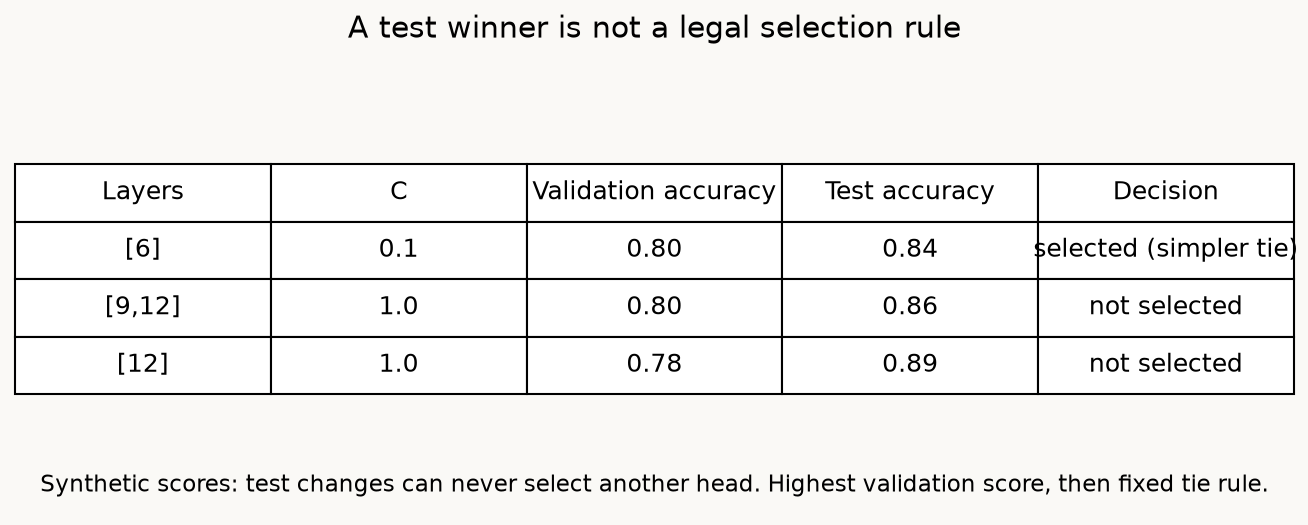" style="width:100%;min-width:720px;max-width:none;height:auto"></div>

Synthetic selection example. A tie is resolved without looking at test accuracy; the best test score is not a permitted selection rule. [Full-size figure](figures/l065/selection-v2.png).

The selected head is refitted deterministically on the same outer training representations, using the chosen layers and C. Validation rows are not promoted into its training set. The native baseline has no local head search. Layers 6, 9 and 12 each get the same three-value C grid. The vanilla diagnostic fits a head on labeled-context layer-12 states and applies it to query states. A raw-feature head uses train-fitted imputation and scaling plus the same C grid. This reveals whether the extracted representation offers anything beyond a simple head on the original table under these choices.

More search does not guarantee better test accuracy. If two candidates' validation accuracies differ by one row, the selected winner can reverse on the untouched test set. The widget illustrates that selection logic on a synthetic table, not on the measured datasets. It never lets the test column choose the winner. The resulting local combined head has more selection opportunities than each fixed layer, so a comparison includes both representation choice and search capacity.

## Predict before viewing the measurements

Write three predictions: whether the context-role head will have a larger train/test gap; whether layer 12 must beat layer 6 on every split; and whether the validation-selected combination must beat the native predictor on test. Explain the word “must” in each answer. A failure of the last two predictions need not indicate a coding bug.

<div style="max-width:100%;overflow-x:auto" role="region" aria-label="Scrollable computational figure"><img alt="Fresh author measurement on full diabetes, blood transfusion and WDBC: three overlapping stratified split seeds, ten extraction folds, one numeric view. Dots are individual runs, not confidence intervals or independent datasets." src="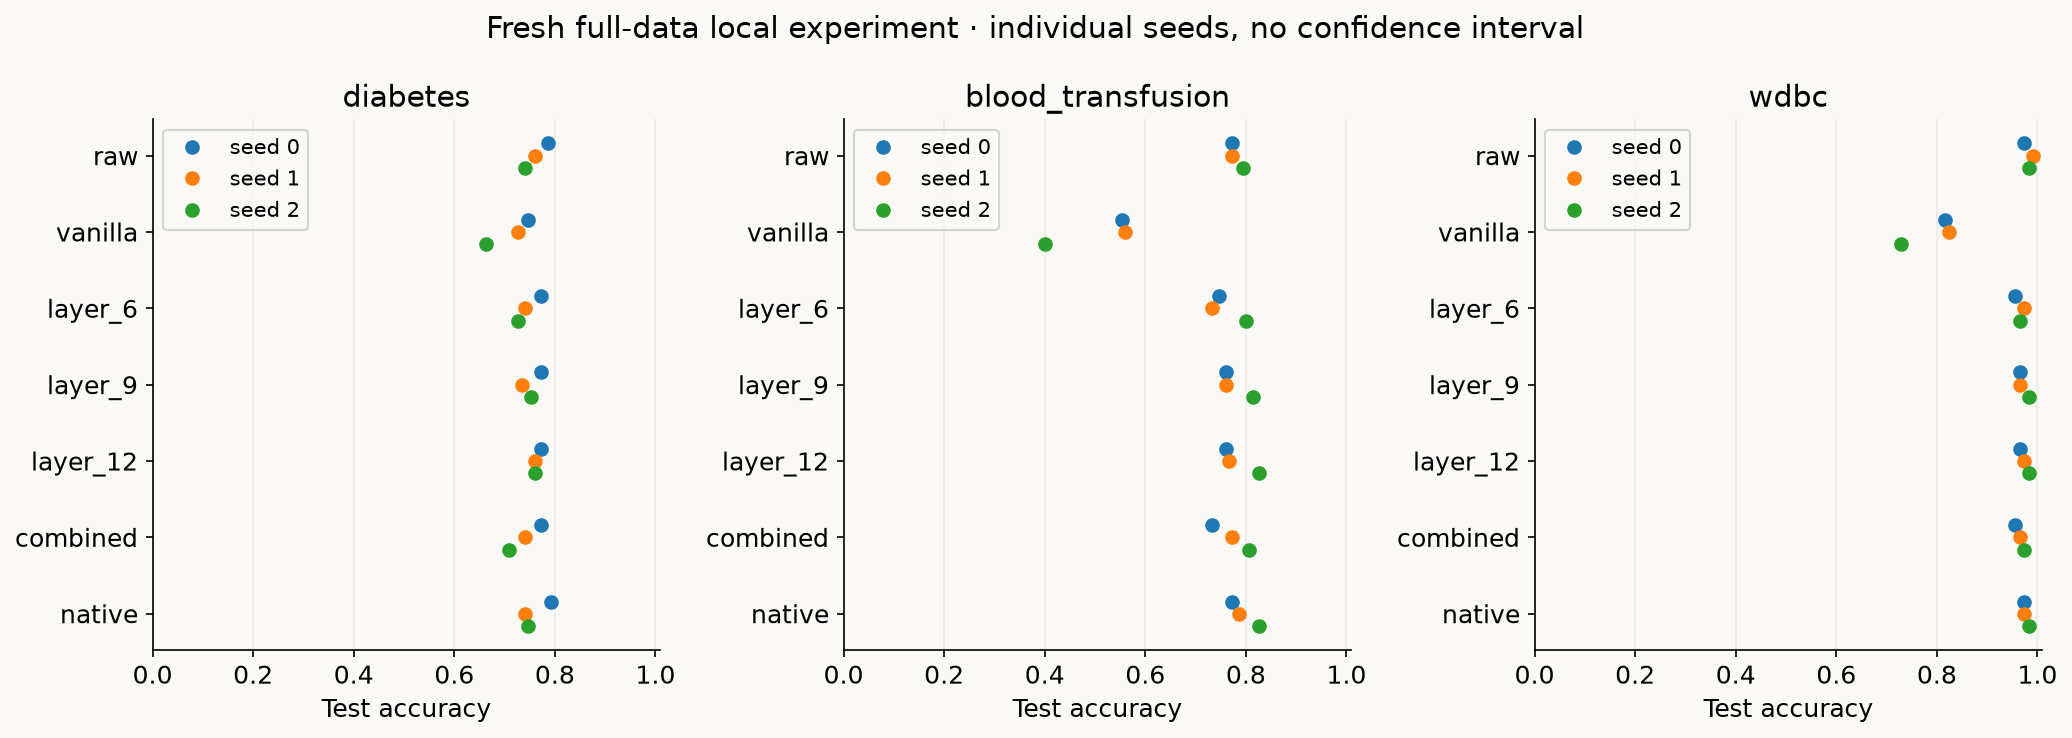" style="width:100%;min-width:1100px;max-width:none;height:auto"></div>

Fresh author measurement on full diabetes, blood transfusion and WDBC: three overlapping stratified split seeds, ten extraction folds, one numeric view. Dots are individual runs, not confidence intervals or independent datasets. [Full-size figure](figures/l065/results-v2.png).

The fresh author experiment uses every row of diabetes (768), blood transfusion (748) and WDBC (569), with three stratified split seeds. Each dataset supplies three overlapping train/validation/test partitions, not three independent datasets. Accuracy is the selection metric; test log loss and ROC AUC are also saved. The plot shows every measured seed rather than confidence intervals suggesting a larger population of tasks. The [full evidence](_verify_l065_v2_results.json) includes IDs, fold contexts, class axes, logits, targets, candidate validation scores, selected heads, fitted scaler parameters, coefficients, probabilities, timings and executable identities.

All arms use the same outer rows per seed. The experiment supports comparisons on these numeric tasks under one explicit recipe. It does not establish the average rank in the paper's different 29-dataset pool, categorical handling, 15-seed evaluation, or original default multi-view preprocessing. A visible selected-layer result is a result of the full pipeline, not an intrinsic quality certificate for that layer.

Mean test accuracy across the three saved seeds is shown below. These are local descriptive means; each dataset receives its own row, and the individual runs remain visible above.

| Dataset | Raw | Vanilla | Layer 6 | Layer 9 | Layer 12 | Combined | Native |
|---|---:|---:|---:|---:|---:|---:|---:|
| diabetes | 0.7619 | 0.7121 | 0.7468 | 0.7532 | 0.7641 | 0.7403 | 0.7597 |
| blood_transfusion | 0.7800 | 0.5044 | 0.7600 | 0.7778 | 0.7844 | 0.7711 | 0.7956 |
| wdbc | 0.9825 | 0.7895 | 0.9649 | 0.9708 | 0.9737 | 0.9649 | 0.9766 |

The selected combination does not beat native v2 on any of these nine test splits (one tie). Raw features also remain competitive. This is useful negative evidence about this local extraction/search recipe, not a refutation of the paper’s different benchmark. The vanilla head is especially weak on blood transfusion despite highly accurate fitted training predictions; inspect the paired scores below before attributing separability to a useful deployment representation.

<div style="max-width:100%;overflow-x:auto" role="region" aria-label="Scrollable computational figure"><img alt="Fresh local fitted-training versus untouched-test accuracy for the context-role, query-role and raw-feature heads. Each connected pair is one seed; fitted training accuracy is not a generalization estimate." src="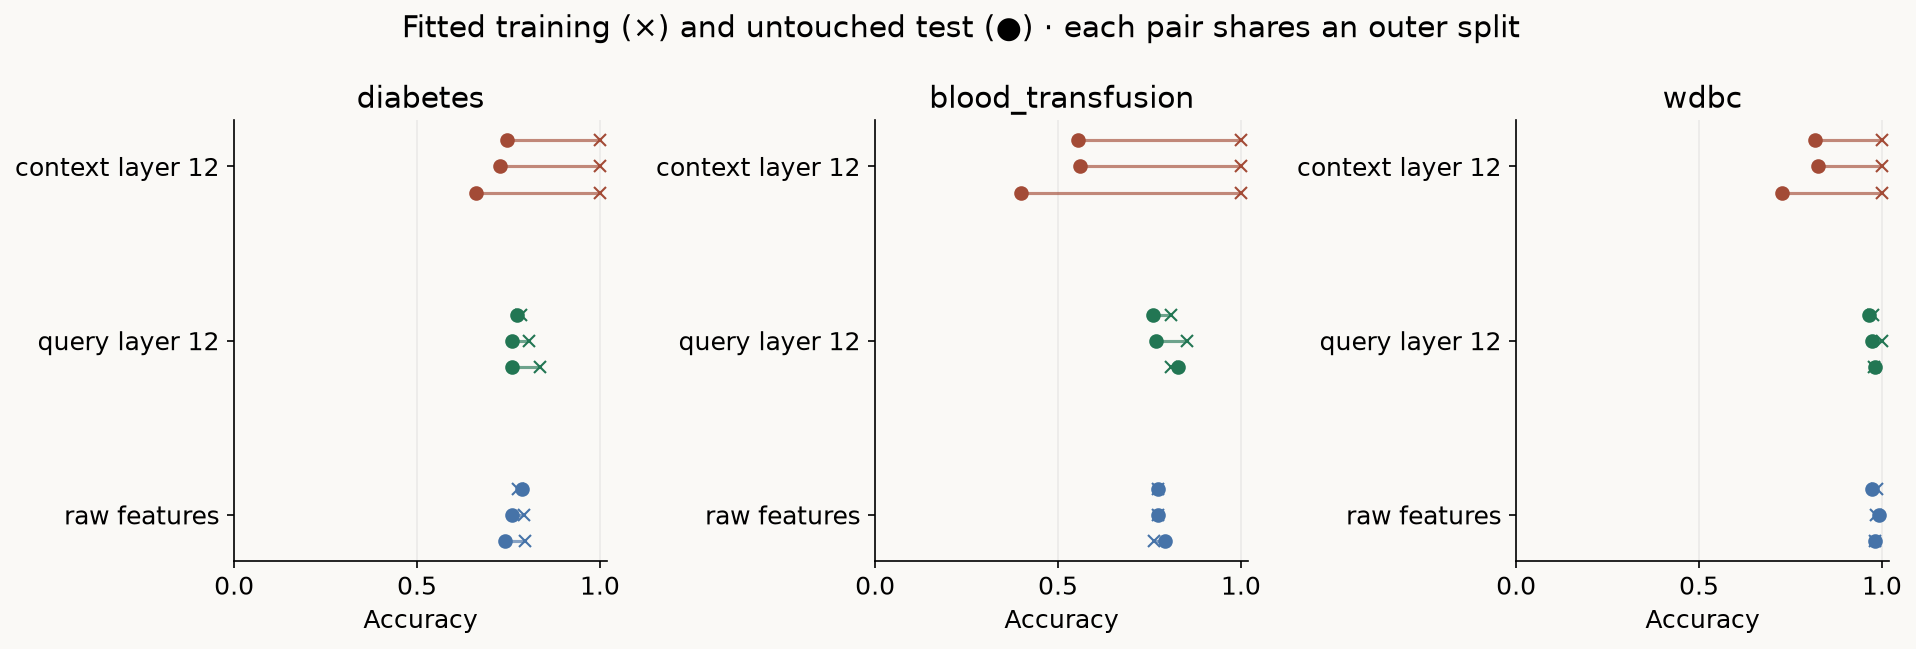" style="width:100%;min-width:1100px;max-width:none;height:auto"></div>

Fresh local fitted-training versus untouched-test accuracy for the context-role, query-role and raw-feature heads. Each connected pair is one seed; fitted training accuracy is not a generalization estimate. [Full-size figure](figures/l065/gaps-v2.png).

The connected pairs diagnose the role mismatch more directly than a two-dimensional scatter plot. Compare the context-role and query-role layer-12 heads on the same split. Both heads fit training targets, so both can have a training/test gap. A larger gap in the context arm is consistent with exploiting information unavailable to queries; the fixed-label intervention independently establishes the own-label route. This plot alone cannot attribute every part of the gap to that route because the two representation distributions and fitted heads also differ.

## Diagnose a mismatch before making a claim

If source states disagree, inspect layer numbering, target-token axis, input dtype, context/query order, constant filtering and group-identity seed before comparing predictive scores. The source checker compares every target state against actual 2.0.9 layer hooks, then independently checks final states through `get_embeddings`. It validates this numeric recipe and fixture; the full backbone forward/gradient/default-wrapper evidence remains in Lesson 064.

If the scatter CHECK fails, log original IDs at both sides of the callback. If the vanilla head looks suspiciously good on training data, compare its fitted score with query-role test performance and the own-label intervention. If the combined head wins validation but loses test, inspect its selected layers and validation margin without selecting a replacement on test. If changing a held-out label changes its query vector, check whether your test also changed folds, context labels, preprocessing, or the query batch.

The notebook records the **live** functions, nested helper dependencies, defaults, model methods, protocol and versions, plus a digest of actual model tensors. Editing a helper used inside a generator expression must change that identity. Source checks and measured outputs must share it. A stale result cannot become current merely by relabeling its file. The lab has no resume path: after an executable change, rerun checks and measurements.

## Your exit artifact and next experiment

Complete the four TODOs and their CHECKs, run the full pretrained diabetes experiment, and write an interpretation. EXIT requires the saved source-check identity, current weight digest, ten-fold row ledger, all candidate validation scores, actual probabilities and an explanation of the remaining context-distribution shift. The notebook writes a separate student artifact, never overwriting author evidence.

Teach this back: how can a frozen encoder leak an answer, why does fold extraction help, and why is the head's training score still optimistic? In a relational system, which entity ID and timestamp checks would replace our row-ID exclusion? Ask the teacher to review your saved artifact and explanation; completing cells is not a mastery record.

For the next experiment, rerun the three-dataset preset through the same live functions. Then investigate the 90% versus 100% context-policy choice with a predeclared validation comparison. A full paper-result reproduction additionally needs the exact 29-task source versions, split seeds, preprocessing, head settings and original selection procedure. The [reproduction contract](l065-reproduction.md) records those unresolved items rather than presenting the local preset as a fidelity certificate.

## PROVIDED · Environment and full backbone
The next chunks implement the complete historical model from Lesson 064. Read them as the dependency of your extraction procedure. Grouping and missing flags preserve the release recipe; blocks do not call the original package. The original package runs only in an isolated source-check process. A learned group projection is added after value encoding; the schematic multiplication in Ye §5 Eq. 2 is not the exact released grouped-feature computation.

In [ ]:
# PROVIDED — deterministic local imports and output directory
import hashlib,importlib.metadata,inspect,itertools,json,math,time,types,sys
from pathlib import Path
import numpy as np
import torch
from torch import nn
from sklearn.model_selection import train_test_split,StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,log_loss,roc_auc_score
for p in [Path.cwd(),Path.cwd()/'labs',Path.cwd().parent]:
    if (p/'relkit').is_dir():ROOT=p.resolve();sys.path.insert(0,str(ROOT));break
else:raise RuntimeError('Run bootstrap or start Jupyter in labs')
torch.set_num_threads(1)
output=ROOT/'data/cache/l065-student';output.mkdir(parents=True,exist_ok=True)

In [ ]:
# PROVIDED — pinned identity and explicit protocol
CHECKPOINT_SHA='f65a35685aeef42e31b796d9bfa34e68d6fc780bc98e7bff7763802964cf435f'
CHECKPOINT_URL='https://huggingface.co/Prior-Labs/TabPFN-v2-clf/resolve/f851f2a3c941544733b712d8c0f96dfae9b28862/tabpfn-v2-classifier.ckpt'
MODEL_CONFIG={'width': 192, 'heads': 6, 'hidden': 768, 'layers': 12, 'classes': 10, 'group_size': 2}
RECIPE={'temperature': 0.9, 'remove_constants': True, 'transform': 'none', 'fingerprint': False, 'feature_permutation': False, 'class_permutation': False, 'cache': False}
PROTOCOL={'folds': 10, 'split': [0.64, 0.16, 0.2], 'C': [0.1, 1.0, 10.0], 'max_layers': 3, 'selection': 'validation accuracy; ties fewer layers, smaller C, lexicographic layers', 'evaluation_context': 'all outer-training rows; validation and test separate fixed query batches', 'seed_policy': 'same group-identity seed in all folds and evaluation', 'recipe': 'one numeric view, context constant removal, no external transform/fingerprint/outlier transform', 'head': 'StandardScaler fit on head-training representations; binary liblinear L2 logistic regression, max_iter=2000, tol=1e-6'}
PRESETS65={'lab': {'datasets': ['diabetes'], 'seeds': [7]}, 'closer': {'datasets': ['diabetes', 'blood_transfusion', 'wdbc'], 'seeds': [0, 1, 2]}}

### PROVIDED · Feature and target inputs

Trace the tensor axes against the architecture figure. These definitions execute in your notebook namespace; a changed helper changes the model used by source checks and the experiment.

In [ ]:
# PROVIDED — group_features
def group_features(x,group_size=2):
    """B×N×F -> B×N×ceil(F/g)×g, preserving row/feature identities."""
    if x.ndim!=3 or group_size<1 or x.shape[-1]<1:raise ValueError('Expected B,N,F and positive group size')
    padding=(-x.shape[-1])%group_size
    return nn.functional.pad(x,(0,padding)).reshape(*x.shape[:2],-1,group_size)

In [ ]:
# PROVIDED — impute_with_flags
def impute_with_flags(x,n):
    """Context mean replacement; flags 0 observed, -2 NaN, +2/+4 infinities.

    The numeric wrapper rejects infinities. This helper retains source low-level
    semantics for independent encoder comparisons.
    """
    context=x[:,:n];valid=~torch.isnan(context)
    means=torch.where(valid,context,0).sum(1)/valid.sum(1).clamp_min(1)
    flags=(torch.isnan(x)*-2+torch.isposinf(x)*2+torch.isneginf(x)*4).to(x.dtype)
    filled=torch.where(torch.isfinite(x),x,means[:,None])
    return filled,flags

In [ ]:
# PROVIDED — soften_outliers
def soften_outliers(x,n,sigma):
    """Context two-pass bounds and logarithmic tail compression from v2 source."""
    context=x[:,:n]
    mean=context.mean(1,keepdim=True);std=context.std(1,correction=1,keepdim=True)
    clean=torch.where((context<mean-sigma*std)|(context>mean+sigma*std),float('nan'),context)
    mask=~torch.isnan(clean);count=mask.sum(1,keepdim=True)
    mean=torch.where(mask,clean,0).sum(1,keepdim=True)/count.clamp_min(1)
    std=torch.sqrt(torch.where(mask,(clean-mean).square(),0).sum(1,keepdim=True)/(count-1))
    lower=mean-sigma*std;upper=mean+sigma*std
    x=torch.maximum(-torch.log(1+x.abs())+lower,x)
    return torch.minimum(torch.log(1+x.abs())+upper,x)

In [ ]:
# PROVIDED — encode_groups
def encode_groups(x,n,outlier_sigma=None):
    """Missing replacement -> context sample z-score -> source active-group scaling.

    Active values are counted across ALL supplied rows, matching the historical
    uncached encoder. This is a deliberately exposed boundary, not a guarantee
    of query independence. Flag channels are NOT active-count scaled.
    """
    filled,flags=impute_with_flags(x,n)
    if outlier_sigma is not None:filled=soften_outliers(filled,n,outlier_sigma)
    context=filled[:,:n];mean=context.mean(1,keepdim=True)
    std=context.std(1,correction=1,keepdim=True)+1e-20
    if n==1:std=torch.ones_like(std)
    z=((filled-mean)/std).clamp(-100,100)
    active=(z[:,1:]!=z[:,:1]).any(1).sum(-1,keepdim=True).clamp_min(1)
    z=z*torch.sqrt(x.shape[-1]/active[:,None])
    return torch.cat([z,flags],-1)

In [ ]:
# PROVIDED — encode_targets
def encode_targets(y,total_rows):
    """B×C -> B×N×2: ordinal target and missing flag; query labels unavailable."""
    if y.ndim!=2 or not 1<=y.shape[1]<total_rows or not torch.isfinite(y).all():raise ValueError('Context labels only, with at least one query')
    missing=torch.full((len(y),total_rows-y.shape[1]),float('nan'),dtype=y.dtype,device=y.device)
    values,flags=impute_with_flags(torch.cat([y,missing],1).unsqueeze(-1),y.shape[1])
    ranks=torch.stack([(values[b,...,0,None]>torch.unique(y[b])).sum(-1) for b in range(len(y))]).to(y.dtype)
    return torch.stack([ranks,flags[...,0]],-1)

### PROVIDED · Attention and residual updates

Trace the tensor axes against the architecture figure. These definitions execute in your notebook namespace; a changed helper changes the model used by source checks and the experiment.

In [ ]:
# PROVIDED — attention_mix
def attention_mix(q,k,v):
    """...×H×receivers×d -> weighted values; K/V may broadcast one head."""
    if q.shape[-1]!=k.shape[-1] or k.shape[-2]!=v.shape[-2]:raise ValueError('Attention shape mismatch')
    # Historical CPU branch rounds the inverse-square-root scalar to float32.
    scale=torch.sqrt(torch.tensor(1.0/q.shape[-1])).to(q.device)
    return ((q@k.transpose(-2,-1))*scale).softmax(-1)@v

In [ ]:
# PROVIDED — PackedAttention
class PackedAttention(nn.Module):
    def __init__(self,width,heads):
        super().__init__();self.heads=heads;self.width=width
        self.qkv=nn.Parameter(torch.empty(3,heads,width//heads,width))
        self.out=nn.Parameter(torch.empty(heads,width//heads,width))
        nn.init.normal_(self.qkv,std=.02);nn.init.normal_(self.out,std=.02)
    def forward(self,receivers,senders=None,first_kv=False):
        senders=receivers if senders is None else senders
        q=torch.einsum('...sd,hkd->...hsk',receivers,self.qkv[0])
        weights=self.qkv[1:,:1] if first_kv else self.qkv[1:]
        k,v=torch.einsum('...sd,jhkd->j...hsk',senders,weights)
        mixed=attention_mix(q,k,v)
        return torch.einsum('...hsk,hkd->...sd',mixed,self.out)

In [ ]:
# PROVIDED — row_attention
def row_attention(h,n,attention):
    """B,N,G,D -> B,N,G,D; context MHA, query first-head-KV MQA."""
    if h.ndim!=4 or not 1<=n<h.shape[1]:raise ValueError('Context/query row split')
    rows=h.transpose(1,2)
    context=rows[:,:,:n];query=rows[:,:,n:]
    context_update=attention(context,context)
    query_update=attention(query,context,first_kv=True)
    return torch.cat([context_update,query_update],2).transpose(1,2)

In [ ]:
# PROVIDED — postnorm_update
def postnorm_update(h,update):
    """Every sublayer adds its input BEFORE non-affine LayerNorm(eps=1e-5)."""
    return nn.functional.layer_norm(h+update,(h.shape[-1],),eps=1e-5)

### PROVIDED · All twelve complete blocks and native head

Trace the tensor axes against the architecture figure. These definitions execute in your notebook namespace; a changed helper changes the model used by source checks and the experiment.

In [ ]:
# PROVIDED — V2Block
class V2Block(nn.Module):
    def __init__(self,width=192,heads=6,hidden=768):
        super().__init__();self.feature=PackedAttention(width,heads);self.row=PackedAttention(width,heads)
        self.ff1=nn.Linear(width,hidden,bias=False);self.ff2=nn.Linear(hidden,width,bias=False)
    def forward(self,h,n):
        h=postnorm_update(h,self.feature(h))
        h=postnorm_update(h,row_attention(h,n,self.row))
        return postnorm_update(h,self.ff2(nn.functional.gelu(self.ff1(h))))

In [ ]:
# PROVIDED — TabPFNv2
class TabPFNv2(nn.Module):
    def __init__(self,width=192,heads=6,hidden=768,layers=12,classes=10,group_size=2):
        super().__init__();self.config=dict(width=width,heads=heads,hidden=hidden,layers=layers,classes=classes,group_size=group_size)
        self.x_encoder=nn.Linear(2*group_size,width,bias=False);self.y_encoder=nn.Linear(2,width)
        self.position=nn.Linear(width//4,width)
        self.blocks=nn.ModuleList([V2Block(width,heads,hidden) for _ in range(layers)])
        self.head=nn.Sequential(nn.Linear(width,hidden),nn.GELU(),nn.Linear(hidden,classes))
    def forward(self,x,y,seed=0,return_hidden=False,outlier_sigma=None):
        if x.ndim!=3 or y.ndim!=2 or x.shape[0]!=y.shape[0]:raise ValueError('x:B,N,F; y:B,C')
        n=y.shape[1];groups=group_features(x,self.config['group_size'])
        features=self.x_encoder(encode_groups(groups,n,outlier_sigma))
        generator=torch.Generator(device=x.device).manual_seed(seed)
        random_ids=torch.randn((groups.shape[2],self.config['width']//4),generator=generator,device=x.device,dtype=x.dtype)
        features=features+self.position(random_ids)[None,None]
        target=self.y_encoder(encode_targets(y.to(x.dtype),x.shape[1]))
        h=torch.cat([features,target.unsqueeze(2)],2)
        for block in self.blocks:h=block(h,n)
        logits=self.head(h[:,n:,-1])
        return (logits,h) if return_hidden else logits

### PROVIDED · Strict copied weights and complete numeric data

Trace the tensor axes against the architecture figure. These definitions execute in your notebook namespace; a changed helper changes the model used by source checks and the experiment.

In [ ]:
# PROVIDED — load_pretrained
def load_pretrained(path,model=None):
    path=Path(path)
    if hashlib.sha256(path.read_bytes()).hexdigest()!=CHECKPOINT_SHA:raise ValueError('Unexpected v2 checkpoint bytes')
    saved=torch.load(path,map_location='cpu',weights_only=False)
    model=TabPFNv2(**MODEL_CONFIG) if model is None else model
    mapped={}
    for key,value in saved['state_dict'].items():
        key=key.replace('encoder.5.layer.','x_encoder.').replace('y_encoder.2.layer.','y_encoder.').replace('feature_positional_embedding_embeddings.','position.').replace('decoder_dict.standard.','head.')
        key=key.replace('transformer_encoder.layers.','blocks.').replace('self_attn_between_features._w_','feature.').replace('self_attn_between_items._w_','row.').replace('mlp.linear1.','ff1.').replace('mlp.linear2.','ff2.')
        mapped[key]=value
    model.load_state_dict(mapped,strict=True);model.eval()
    return model,saved['config']

In [ ]:
# PROVIDED — ensure_checkpoint
def ensure_checkpoint(root):
    import urllib.request
    path=Path(root)/'data/cache/foundation/tabpfn-v2.ckpt';path.parent.mkdir(parents=True,exist_ok=True)
    if not path.exists():
        partial=path.with_suffix('.partial');urllib.request.urlretrieve(CHECKPOINT_URL,partial)
        if hashlib.sha256(partial.read_bytes()).hexdigest()!=CHECKPOINT_SHA:raise ValueError('Downloaded checkpoint checksum')
        partial.replace(path)
    if hashlib.sha256(path.read_bytes()).hexdigest()!=CHECKPOINT_SHA:raise ValueError('Cached checkpoint checksum')
    return path

In [ ]:
# PROVIDED — load_dataset
def load_dataset(name):
    """All rows, numeric paper datasets. wdbc is sklearn's same UCI source (569×30)."""
    if name=='wdbc':
        from sklearn.datasets import load_breast_cancer
        data=load_breast_cancer();x=data.data;y=data.target
    else:
        from relkit.data import load_tier_a
        x,y=load_tier_a(name);x=np.asarray(x,dtype=np.float32);y=np.asarray(y)
    _,y=np.unique(y,return_inverse=True)
    return np.asarray(x,dtype=np.float32),y

## TODO 1 · Read the correct token and row role

**Goal:** Return B×Q×192 for query or B×C×192 for context. Validate rank, context boundary and role.

**Why:** The last token is a target token; the last row is only one row.

**Hint boundary:** Use separate slices for row role and target-token position.

In [ ]:
# TODO — extract_target_states
def extract_target_states(hidden,n_context,role='query'):
    raise NotImplementedError("Implement this live query-embedding operation")

In [ ]:
# CHECK — extract_target_states
h=torch.arange(1*5*3*4.).reshape(1,5,3,4)
assert torch.equal(extract_target_states(h,3),h[:,3:,2,:])
assert extract_target_states(h,4).shape==(1,1,4), 'Keep a singleton query row axis'
assert torch.equal(extract_target_states(h,3,'context'),h[:,:3,2,:])
print("CHECK passed: extract_target_states")

## TODO 2 · Restore original row identities

**Goal:** Call extractor with context/query positions for every fold; return N×L×D plus a list of context/query position traces. Validate exactly one write per row.

**Why:** A fold concatenation can preserve shape while changing which label belongs to each vector.

**Hint boundary:** Allocate after the first result. Use original query positions as destinations.

In [ ]:
# TODO — scatter_fold_embeddings
def scatter_fold_embeddings(n_rows,folds,extractor):
    raise NotImplementedError("Implement this live query-embedding operation")

In [ ]:
# CHECK — scatter_fold_embeddings
folds=np.array([1,0,1,0,2,2]);seen=[]
def identity_probe(c,q):
    assert not set(c)&set(q);seen.extend(q.tolist())
    return np.broadcast_to(q[:,None,None],(len(q),12,3)).copy()
z,trace=scatter_fold_embeddings(6,folds,identity_probe)
assert np.array_equal(z[:,0,0],np.arange(6)) and sorted(seen)==list(range(6))
assert len(trace)==3
print("CHECK passed: scatter_fold_embeddings")

## TODO 3 · Preserve distinct layer coordinates

**Goal:** Select one to three distinct one-based layers from N×L×D; return N×(rD) in the requested order.

**Why:** An average cannot give the head independent coefficients for each layer.

**Hint boundary:** Validate layer IDs before selecting and concatenate on the coordinate axis.

In [ ]:
# TODO — concatenate_layers
def concatenate_layers(embeddings,layers):
    raise NotImplementedError("Implement this live query-embedding operation")

In [ ]:
# CHECK — concatenate_layers
z=np.arange(3*12*2).reshape(3,12,2)
c=concatenate_layers(z,[6,9,12])
assert c.shape==(3,6) and np.array_equal(c,np.concatenate([z[:,5],z[:,8],z[:,11]],1))
print("CHECK passed: concatenate_layers")

## TODO 4 · Freeze a validation-only decision

**Goal:** Choose highest validation_accuracy; ties fewer layers, smaller C, then lexicographic layers.

**Why:** The test set must never select the layer or its regularization.

**Hint boundary:** Use a deterministic comparison key; each candidate contains only validation fields.

In [ ]:
# TODO — choose_candidate
def choose_candidate(candidates):
    raise NotImplementedError("Implement this live query-embedding operation")

In [ ]:
# CHECK — choose_candidate
candidates=[dict(layers=[6,9],C=1.,validation_accuracy=.8),dict(layers=[12],C=1.,validation_accuracy=.8),dict(layers=[6],C=.1,validation_accuracy=.7)]
assert choose_candidate(candidates)==candidates[1]
assert all('test_accuracy' not in c for c in candidates)
print("CHECK passed: choose_candidate")

## PROVIDED · Extract every layer and fit a visible logistic head
The hook captures each complete block output. Your token selector is called for both roles at all twelve layers. The hook handles are removed even if a forward fails. Constant filtering uses the context only. The solver below receives only train-standardized embeddings; validation is transformed with the training mean and scale. It fits actual coefficients rather than reading a stored score. Head optimization is the peripheral library operation; your live selection and concatenation functions determine every candidate.

In [ ]:
# PROVIDED — extract_embeddings
def extract_embeddings(model,context_x,context_y,query_x,seed=0,namespace=None):
    ns=globals() if namespace is None else namespace
    cx=np.asarray(context_x,dtype=np.float32);qx=np.asarray(query_x,dtype=np.float32)
    classes,y=np.unique(context_y,return_inverse=True)
    if len(classes)!=2 or np.isinf(cx).any() or np.isinf(qx).any():raise ValueError('Local lane supports binary finite-or-NaN numeric data')
    keep=(cx==cx[:1]).mean(0)<1
    if not keep.any():raise ValueError('No variable columns')
    x=torch.tensor(np.concatenate([cx[:,keep],qx[:,keep]]))[None];labels=torch.tensor(y,dtype=x.dtype)[None]
    states=[];handles=[]
    def capture(module,args,output):states.append(output.detach())
    try:
        for block in model.blocks:handles.append(block.register_forward_hook(capture))
        model.eval()
        with torch.no_grad():logits=model(x,labels,seed=seed)[0,:,:len(classes)]
    finally:
        for handle in handles:handle.remove()
    query=torch.stack([ns['extract_target_states'](h,len(cx),'query')[0] for h in states],1).numpy()
    context=torch.stack([ns['extract_target_states'](h,len(cx),'context')[0] for h in states],1).numpy()
    return dict(query=query,context=context,logits=logits.numpy(),probabilities=(logits/.9).softmax(-1).numpy(),classes=classes,kept_columns=np.flatnonzero(keep))

In [ ]:
# PROVIDED — fit_head
def fit_head(train,y,C):
    scaler=StandardScaler().fit(train);scaled=scaler.transform(train)
    head=LogisticRegression(C=C,solver='liblinear',max_iter=2000,tol=1e-6,random_state=0).fit(scaled,y)
    if int(head.n_iter_.max())>=2000:raise RuntimeError('Head did not converge')
    return scaler,head

In [ ]:
# PROVIDED — fit_candidates
def fit_candidates(train,y,valid,valid_y,layer_sets,namespace=None):
    ns=globals() if namespace is None else namespace;candidates=[]
    for layers in layer_sets:
        a=ns['concatenate_layers'](train,layers);b=ns['concatenate_layers'](valid,layers)
        for C in PROTOCOL['C']:
            scaler,head=fit_head(a,y,C);p=head.predict_proba(scaler.transform(b))
            candidates.append(dict(layers=list(layers),C=C,validation_accuracy=float(accuracy_score(valid_y,p.argmax(1))),validation_log_loss=float(log_loss(valid_y,p))))
    selected=ns['choose_candidate'](candidates)
    scaler,head=fit_head(ns['concatenate_layers'](train,selected['layers']),y,selected['C'])
    return selected,candidates,scaler,head

In [ ]:
# PROVIDED — metric_record
def metric_record(y,p):
    return dict(accuracy=float(accuracy_score(y,p.argmax(1))),log_loss=float(log_loss(y,p)),auc=float(roc_auc_score(y,p[:,1])),probabilities=p.tolist())

## PROVIDED · Evidence identity and the full experiment
Read run_experiment before running it: outer IDs split first, training folds next, scatter next, validation candidates next, test scoring last. Validation and test use all outer training rows as context in separate calls. The native, raw-feature, vanilla and fixed-layer arms are explicit. The identity traverses global dependencies inside nested code, so editing a selector called within a list comprehension is detectable. It records defaults, model methods, configuration, versions and the data source. The weight digest catches post-measurement model edits.

In [ ]:
# PROVIDED — model_digest
def model_digest(model):
    digest=hashlib.sha256()
    for name,tensor in model.state_dict().items():digest.update(name.encode());digest.update(tensor.detach().cpu().numpy().tobytes())
    return digest.hexdigest()

In [ ]:
# PROVIDED — stable_value
def stable_value(value):
    if value is None or isinstance(value,(str,int,float,bool)):return value
    if value is Ellipsis:return 'Ellipsis'
    if isinstance(value,np.generic):return value.item()
    if isinstance(value,(list,tuple)):return [stable_value(v) for v in value]
    if isinstance(value,dict):return {str(k):stable_value(v) for k,v in value.items()}
    if isinstance(value,(set,frozenset)):return sorted([stable_value(v) for v in value],key=repr)
    if isinstance(value,bytes):return value.hex()
    if isinstance(value,types.CodeType):return {k:stable_value(getattr(value,k)) for k in ['co_code','co_consts','co_names','co_varnames','co_freevars','co_cellvars','co_argcount','co_posonlyargcount','co_kwonlyargcount','co_flags']}
    if inspect.isfunction(value):return dict(code=stable_value(value.__code__),defaults=stable_value(value.__defaults__),kwdefaults=stable_value(value.__kwdefaults__),closure=stable_value([c.cell_contents for c in (value.__closure__ or [])]))
    if isinstance(value,Path):return str(value)
    if inspect.isclass(value):return value.__module__+'.'+value.__qualname__
    raise TypeError(str(type(value)))

In [ ]:
# PROVIDED — kernel_identity
def kernel_identity(namespace,root):
    """Explicit roots plus recursive globals in ALL nested code; stable across processes."""
    from relkit import tabpfn_l064_v2 as backbone
    roots=['extract_target_states','scatter_fold_embeddings','concatenate_layers','choose_candidate','extract_embeddings','fit_head','fit_candidates','metric_record','run_experiment']
    seen={}
    def visit(name,obj):
        if name in seen:return
        if inspect.isclass(obj):
            seen[name]={k:stable_value(v) for k,v in vars(obj).items() if inspect.isfunction(v)}
            for k,v in vars(obj).items():
                if inspect.isfunction(v):visit(name+'.'+k,v)
        elif inspect.isfunction(obj):
            seen[name]=stable_value(obj)
            def scan(code):
                for n in code.co_names:
                    v=obj.__globals__.get(n)
                    if inspect.isfunction(v) and (v.__module__.startswith('relkit') or v.__globals__ is namespace):visit(n,v)
                    elif inspect.isclass(v) and v.__module__ in ('relkit.tabpfn_l064_v2','__main__'):visit(n,v)
                for v in code.co_consts:
                    if isinstance(v,types.CodeType):scan(v)
            scan(obj.__code__)
    for name in roots:visit(name,namespace[name])
    visit('TabPFNv2',namespace.get('TabPFNv2',backbone.TabPFNv2))
    from relkit.data import load_tier_a
    result=dict(operators=seen,config=namespace.get('PROTOCOL',PROTOCOL),presets=namespace.get('PRESETS65',PRESETS65),checkpoint_sha256=CHECKPOINT_SHA,backbone_file_sha256=hashlib.sha256(Path(backbone.__file__).read_bytes()).hexdigest(),loader_file_sha256=hashlib.sha256(Path(inspect.getfile(load_tier_a)).read_bytes()).hexdigest(),versions={k:importlib.metadata.version(k) for k in ['torch','numpy','scikit-learn','scipy']})
    result['loader_globals']={k:stable_value(load_tier_a.__globals__[k]) for k in ['SPECS','CACHE']}
    result['backbone_constants']={k:stable_value(namespace.get(k,getattr(backbone,k))) for k in ['CHECKPOINT_SHA','CHECKPOINT_URL','MODEL_CONFIG','RECIPE']}
    result['sha256']=hashlib.sha256(json.dumps(result,sort_keys=True).encode()).hexdigest();return result

In [ ]:
# PROVIDED — run_experiment
def run_experiment(root,model,config=None,namespace=None):
    ns=globals() if namespace is None else namespace;config=dict(PRESETS65['lab'] if config is None else config);records=[]
    identity=kernel_identity(ns,root);weights=model_digest(model)
    for dataset in config['datasets']:
        x,y=load_dataset(dataset);ids=np.arange(len(y));data_sha=hashlib.sha256(x.tobytes()+y.tobytes()).hexdigest()
        for seed in config['seeds']:
            start=time.perf_counter();trainvalid,test=train_test_split(ids,test_size=.2,stratify=y,random_state=seed)
            train,valid=train_test_split(trainvalid,test_size=.2,stratify=y[trainvalid],random_state=seed)
            fold_ids=np.empty(len(train),int)
            for k,(_,q) in enumerate(StratifiedKFold(PROTOCOL['folds'],shuffle=True,random_state=seed).split(x[train],y[train])):fold_ids[q]=k
            forward_traces=[]
            def encoder(c,q):
                z=ns['extract_embeddings'](model,x[train[c]],y[train[c]],x[train[q]],seed,ns)
                forward_traces.append(dict(context_ids=train[c].tolist(),query_ids=train[q].tolist(),classes=z['classes'].tolist(),kept_columns=z['kept_columns'].tolist(),query_logits=z['logits'].tolist()))
                return z['query']
            ztrain,scatter=ns['scatter_fold_embeddings'](len(train),fold_ids,encoder)
            # Full training context for each evaluation split. No validation/test labels enter.
            zv=ns['extract_embeddings'](model,x[train],y[train],x[valid],seed,ns)
            zt=ns['extract_embeddings'](model,x[train],y[train],x[test],seed,ns)
            extraction_seconds=time.perf_counter()-start;select_start=time.perf_counter()
            layer_sets=list(itertools.chain.from_iterable(itertools.combinations(range(1,13),r) for r in range(1,PROTOCOL['max_layers']+1)))
            chosen,candidates,scaler,head=fit_candidates(ztrain,y[train],zv['query'],y[valid],layer_sets,ns)
            methods={};heads={}
            def score(name,a,b,c,layersets):
                choice,trials,scale,linear=fit_candidates(a,y[train],b,y[valid],layersets,ns)
                features=ns['concatenate_layers'](c,choice['layers']);p=linear.predict_proba(scale.transform(features))
                train_p=linear.predict_proba(scale.transform(ns['concatenate_layers'](a,choice['layers'])))
                methods[name]=metric_record(y[test],p);methods[name]['fitted_train_accuracy']=float(accuracy_score(y[train],train_p.argmax(1)))
                heads[name]=dict(selected=choice,candidates=trials,scaler_mean=scale.mean_.tolist(),scaler_scale=scale.scale_.tolist(),coefficients=linear.coef_.tolist(),intercept=linear.intercept_.tolist(),classes=linear.classes_.tolist())
            p=head.predict_proba(scaler.transform(ns['concatenate_layers'](zt['query'],chosen['layers'])))
            methods['combined']=metric_record(y[test],p)
            heads['combined']=dict(selected=chosen,candidates=candidates,scaler_mean=scaler.mean_.tolist(),scaler_scale=scaler.scale_.tolist(),coefficients=head.coef_.tolist(),intercept=head.intercept_.tolist(),classes=head.classes_.tolist())
            for layer in [6,9,12]:score('layer_'+str(layer),ztrain,zv['query'],zt['query'],[(layer,)])
            score('vanilla',zv['context'],zv['query'],zt['query'],[(12,)])
            imputer=SimpleImputer().fit(x[train]);raw=[imputer.transform(x[v])[:,None,:] for v in [train,valid,test]]
            score('raw',*raw,[(1,)])
            methods['native']=metric_record(y[test],zt['probabilities'])
            record=dict(dataset=dataset,seed=seed,rows=len(y),features=x.shape[1],data_sha256=data_sha,train_ids=train.tolist(),valid_ids=valid.tolist(),test_ids=test.tolist(),train_targets=y[train].tolist(),valid_targets=y[valid].tolist(),test_targets=y[test].tolist(),folds=fold_ids.tolist(),forward_traces=forward_traces,scatter=scatter,embedding_shape=list(ztrain.shape),validation_logits=zv['logits'].tolist(),test_logits=zt['logits'].tolist(),evaluation_classes=zt['classes'].tolist(),evaluation_kept_columns=zt['kept_columns'].tolist(),methods=methods,heads=heads,extraction_seconds=extraction_seconds,selection_seconds=time.perf_counter()-select_start)
            records.append(record);print(dataset,seed,'combined',methods['combined']['accuracy'],'native',methods['native']['accuracy'],'layers',chosen['layers'],flush=True)
    if model_digest(model)!=weights or kernel_identity(ns,root)['sha256']!=identity['sha256']:raise RuntimeError('Kernel or weights changed during measurement')
    return dict(status='MEASURED_PRETRAINED_QUERY_EMBEDDINGS',paper_reproduction='INCOMPARABLE',paper_29_dataset_benchmark='NOT_RUN',protocol=PROTOCOL,config=config,kernel_identity=identity,weights_sha256=weights,checkpoint_sha256=CHECKPOINT_SHA,records=records,timing_boundary='Extraction includes all ten fold forwards and separate validation/test forwards; model/checkpoint loading and source checks excluded. Selection includes all fitted heads and metrics.')

## CHECK · Real historical embeddings, row roles and stale evidence
This checker calls your current functions and constructs your visible model. It obtains all intermediate target states from the original 2.0.9 release, and separately calls its get_embeddings API for final query/context states. It also performs the fixed-membership own-label flip, the identity-coded scatter, the layer-order check and a changed-helper fingerprint check. No source output replaces your experiment's predictions.

In [ ]:
# CHECK — actual live source identity
from _check_l065_v2 import check as source_check
before=kernel_identity(globals(),ROOT)
parity=source_check(globals(),save=False)
assert parity['kernel_sha256']==before['sha256']==kernel_identity(globals(),ROOT)['sha256']
model,checkpoint_config=load_pretrained(ensure_checkpoint(ROOT),TabPFNv2(**MODEL_CONFIG))
weights_before=model_digest(model)
print(json.dumps(parity,indent=2))

In [ ]:
# CHECK — stale helper evidence must be rejected, including a nested call
original=extract_target_states
old_identity=kernel_identity(globals(),ROOT)['sha256']
def altered_selector(*args,**kwargs):return original(*args,**kwargs)*0
extract_target_states=altered_selector
try:
    assert kernel_identity(globals(),ROOT)['sha256']!=old_identity
    try:
        assert parity['kernel_sha256']==kernel_identity(globals(),ROOT)['sha256']
    except AssertionError:print('Stale source verification correctly rejected')
    else:raise AssertionError('Stale source result accepted')
finally:extract_target_states=original
assert parity['kernel_sha256']==kernel_identity(globals(),ROOT)['sha256']

## Predict, then run the full pretrained experiment
Before running, write whether the selected combination must beat native v2 on test, and why cross-fitting does not make the fitted head's training score unbiased. This cell uses all diabetes rows and all 894 validation candidates. It may take several minutes on CPU. Model download/loading and source checks are outside the extraction timer. The current kernel's output stays separate from the author's three-dataset evidence.

In [ ]:
# PROVIDED — genuine local measurement, through all four live TODOs
run_config=dict(PRESETS65['lab'])
assert parity['kernel_sha256']==kernel_identity(globals(),ROOT)['sha256']
result=run_experiment(ROOT,model,run_config,globals())
assert result['kernel_identity']['sha256']==parity['kernel_sha256']
for r in result['records']:
    print(r['dataset'],r['seed'],{k:round(v['accuracy'],4) for k,v in r['methods'].items()})
    print('Selected:',r['heads']['combined']['selected'])

## EXIT · Save a measured, identity-bound result and interpretation
Explain the own-label boundary; give the native and selected-head test scores from your run; identify the selected layers; explain the 90% versus 100% support-size shift. A loss on test is an acceptable result, but selecting another head on that test is not. Replace the interpretation below with your own account. The completed teacher notebook contains a checked example, not a mastery judgment for you.

In [ ]:
# EXIT — required explanation
interpretation='WRITE YOUR INTERPRETATION HERE'
assert len(interpretation)>100 and 'WRITE YOUR' not in interpretation
assert kernel_identity(globals(),ROOT)['sha256']==parity['kernel_sha256']==result['kernel_identity']['sha256']
assert model_digest(model)==weights_before==result['weights_sha256']
assert parity['checker_sha256']==hashlib.sha256((ROOT/'_check_l065_v2.py').read_bytes()).hexdigest()
assert parity['reference_worker_sha256']==hashlib.sha256((ROOT/'_reference_l065_v2.py').read_bytes()).hexdigest()
for r in result['records']:
    assert r['embedding_shape']==[len(r['train_ids']),12,192]
    assert len(set(r['folds']))==10 and len(r['heads']['combined']['candidates'])==894
    assert not (set(r['train_ids'])&set(r['valid_ids']) or set(r['train_ids'])&set(r['test_ids']) or set(r['valid_ids'])&set(r['test_ids']))
result['parity']=parity;result['interpretation']=interpretation
path=output/f'run-{time.time_ns()}.json';path.write_text(json.dumps(result,indent=2)+chr(10))
exit_record=dict(status='MEASURED_PRETRAINED_QUERY_EMBEDDINGS',paper_reproduction='INCOMPARABLE',run_path=str(path),run_sha256=hashlib.sha256(path.read_bytes()).hexdigest(),kernel_sha256=parity['kernel_sha256'],checkpoint_sha256=CHECKPOINT_SHA,interpretation=interpretation)
(output/'student-l065-v2-exit.json').write_text(json.dumps(exit_record,indent=2)+chr(10))
print(json.dumps(exit_record,indent=2))

## NEXT STEP · Same implementation, broader local evidence
The optional closer preset repeats this exact extraction/selection operator on all three numeric datasets and three seeds. It is a replication of our local panel, not the paper's full 29-task benchmark. The reproduction contract identifies the missing paper metadata. Keep your measurement separate; never update an old record's fingerprint to silence a check.

In [ ]:
# PROVIDED — optional local/Colab scale-up, no cloud service is launched
RUN_BROADER=False
if RUN_BROADER:
    assert kernel_identity(globals(),ROOT)['sha256']==parity['kernel_sha256']
    larger=run_experiment(ROOT,model,PRESETS65['closer'],globals())
    (output/f'closer-{time.time_ns()}.json').write_text(json.dumps(larger,indent=2)+chr(10))
else:print('Broader current-kernel run NOT_RUN; full paper benchmark NOT_RUN.')

## Carry this forward

<a href="../lessons/0066-tabicl-column-row-attention.html">TabICL</a> makes row representation construction an explicit early stage. Its pre-ICL vectors are label-free, while its later ICL states are not—the stage name now matters as much as “embedding.”